In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input,SimpleRNN, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, f1_score
from tensorflow.keras.utils import to_categorical
from sklearn.ensemble import RandomForestClassifier
import random
from sklearn.preprocessing import StandardScaler
import json
import joblib 

cols = ['user', 'activity', 'timestamp', 'x-accel', 'y-accel', 'z-accel']
raw_data = pd.read_csv('dataset/wisdm/WISDM_ar_v1.1/WISDM_ar_v1.1_raw.txt', header=None,names=cols, sep=",",on_bad_lines='skip')
raw_data['z-accel'] = raw_data['z-accel'].str.replace(';', '').astype(float)
raw_data.interpolate(method='linear', limit_direction ='both', inplace=True)
#Aktivite ve Kodları:
# 0: Downstairs
# 1: Jogging
# 2: Sitting
# 3: Standing
# 4: Upstairs
# 5: Walking
raw_data['actvity_code'] = raw_data['activity'].astype('category').cat.codes
work_data = raw_data[['user','actvity_code','timestamp', 'x-accel', 'y-accel', 'z-accel']]

C:\Users\aylin\AppData\Local\Temp\ipykernel_17544\3989036727.py:22: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  raw_data.interpolate(method='linear', limit_direction ='both', inplace=True)


In [2]:
sample_frequency = 20
seconds=3
window_size = seconds * sample_frequency #20Hz 3 seconds 20*3=60
feature_count = 3 #x,y,z
step = window_size # for non-overlap segments

segments = []
labels = []

data_for_segmentation = work_data[['x-accel', 'y-accel', 'z-accel']].values
labels_for_segmentation = work_data['actvity_code'].values

for user in work_data['user'].unique():
    for act_code in work_data['actvity_code'].unique():
        s_index = work_data.index[(work_data['user'] == user) & (work_data['actvity_code'] == act_code)].tolist()
        for i in range(0, len(s_index) - window_size, step):
            window_start = s_index[i]
            window_end = window_start + window_size
            
            segment = data_for_segmentation[window_start : window_end]
            label = act_code
            
            segments.append(segment)
            labels.append(label)

reshaped_segments = np.asarray(segments, dtype=np.float32)
labels = np.asarray(labels)
#print(reshaped_segments)

In [3]:
feature_list = []

for i in range(reshaped_segments.shape[0]): #bütün segmentler, 18bin tane yklşk
    segment = reshaped_segments[i]
    segment_features = []
    
    for j in range(segment.shape[1]): #3 ekseni dön, xyz
        data = segment[:, j]
        segment_features.append(np.mean(data))
        segment_features.append(np.min(data))
        segment_features.append(np.max(data))
        segment_features.append(np.std(data))
        segment_features.append(np.median(data))
        segment_features.append(stats.median_abs_deviation(data)) #mad
        segment_features.append(np.sqrt(np.mean(data**2))) #rsm
        segment_features.append(np.sum(data**2)) #enerji - jog/walk yüksek enerji, sit/stand düşük enerji
        
        hist, _ = np.histogram(data, bins=10, density=True)
        segment_features.append(stats.entropy(hist))  #entropi

    feature_list.append(segment_features)
    
#print(len(feature_list))
#print(feature_list[0])
#print(feature_list[1])
feature_extraction = pd.DataFrame(feature_list)

feature_names = ['mean', 'min', 'max', 'std', 'median', 'mad', 'rms', 'energy', 'entropy']
axis_name = ['x', 'y', 'z']
column_names = [f'{axis}_{feat}' for axis in axis_name for feat in feature_names ]
feature_extraction.columns = column_names
y_labels = labels.ravel()
labels = labels.ravel()
num_classes = len(np.unique(labels))
#print(feature_extraction.head())

In [4]:
y_one_hot = to_categorical(labels, num_classes=num_classes)

print(y_one_hot.shape)
print(y_one_hot[0])

X_train_val, X_test, y_train_val, y_test = train_test_split(
    reshaped_segments, y_one_hot, test_size=0.2, random_state=17, stratify=y_one_hot
) 

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=17, stratify=y_train_val
)
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(18012, 6)
[0. 1. 0. 0. 0. 0.]
(10806, 60, 3)
(3603, 60, 3)
(3603, 60, 3)


113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

  Downstairs       0.00      0.00      0.00       331
     Jogging       0.92      0.96      0.94      1119
     Sitting       0.97      0.88      0.92       197
    Standing       0.84      0.92      0.88       159
    Upstairs       0.53      0.23      0.32       406
     Walking       0.71      0.97      0.82      1391

    accuracy                           0.79      3603
   macro avg       0.66      0.66      0.65      3603
weighted avg       0.71      0.79      0.73      3603



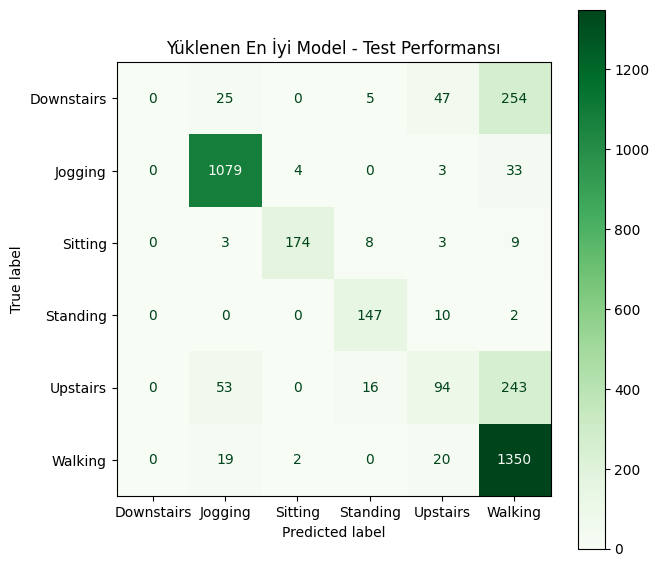

In [5]:
loaded_model = load_model('models_for_yontem2/wisdm/best_simple_rnn_model_wisdm_yontem2.keras')

y_test_pred_probs = loaded_model.predict(X_test)
y_test_pred = np.argmax(y_test_pred_probs, axis=1)
y_test_true = np.argmax(y_test, axis=1)

activity_labels_map = raw_data[['actvity_code', 'activity']].drop_duplicates().sort_values('actvity_code')
activity_names = activity_labels_map['activity'].tolist()

print(classification_report(y_test_true, y_test_pred, target_names=activity_names, zero_division=0))

figure, axes = plt.subplots(figsize=(7, 7))
ConfusionMatrixDisplay.from_predictions(
    y_test_true, 
    y_test_pred,
    display_labels=activity_names, 
    cmap='Greens', 
    xticks_rotation='horizontal', 
    ax=axes
)
plt.title('Yüklenen En İyi Model - Test Performansı')
plt.show()

113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

  Downstairs       0.72      0.41      0.52       331
     Jogging       0.96      0.97      0.96      1119
     Sitting       0.99      0.95      0.97       197
    Standing       0.95      0.99      0.97       159
    Upstairs       0.63      0.62      0.62       406
     Walking       0.87      0.96      0.91      1391

    accuracy                           0.87      3603
   macro avg       0.85      0.82      0.83      3603
weighted avg       0.87      0.87      0.87      3603



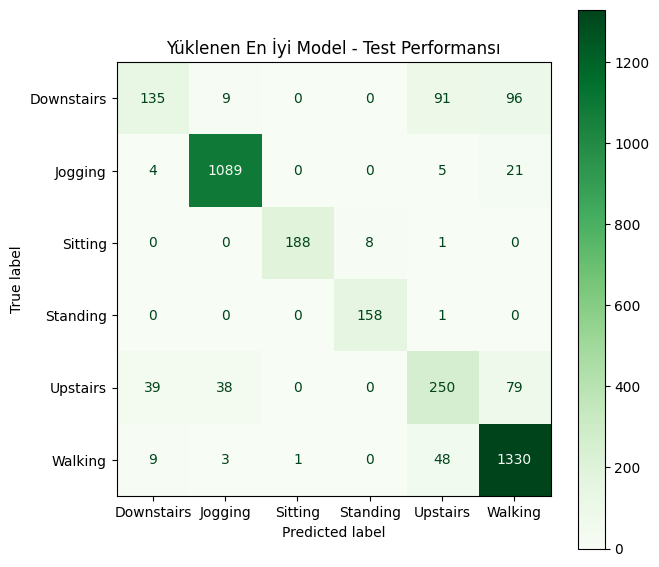

In [6]:
loaded_scaler = joblib.load('models_for_yontem2/wisdm/simple_rnn_with_fs_scaler.joblib')
with open('models_for_yontem2/wisdm/selected_feature_names.txt', 'r') as f:
    selected_feature_names = [line.strip() for line in f]

X_features_selected = feature_extraction[selected_feature_names]
X_features_selected_scaled = loaded_scaler.transform(X_features_selected)

features_3d = np.expand_dims(X_features_selected_scaled, axis=1)
features_corrert_size = np.tile(features_3d, (1, window_size, 1))
X_combined = np.concatenate([reshaped_segments, features_corrert_size], axis=2)

X_train_val_with_fs, X_test_with_fs, y_train_val_with_fs, y_test_with_fs = train_test_split(
    X_combined, y_one_hot, test_size=0.2, random_state=17, stratify=y_one_hot
) 
X_train_with_fs, X_val_with_fs, y_train_with_fs, y_val_with_fs = train_test_split(
    X_train_val_with_fs, y_train_val_with_fs, test_size=0.25, random_state=17, stratify=y_train_val_with_fs
)

model_with_fs= load_model('models_for_yontem2/wisdm/simple_rnn_with_fs_wisdm_yontem2.keras')

y_test_pred_probs_with_fs = model_with_fs.predict(X_test_with_fs)
y_test_pred_with_fs = np.argmax(y_test_pred_probs_with_fs, axis=1)
y_test_true_with_fs = np.argmax(y_test_with_fs, axis=1)

print(classification_report(y_test_true_with_fs, y_test_pred_with_fs, target_names=activity_names, zero_division=0))

figure, axes = plt.subplots(figsize=(7, 7))
ConfusionMatrixDisplay.from_predictions(
    y_test_true_with_fs, 
    y_test_pred_with_fs,
    display_labels=activity_names, 
    cmap='Greens', 
    xticks_rotation='horizontal', 
    ax=axes
)
plt.title('Yüklenen En İyi Model - Test Performansı')
plt.show()